In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("retail_sales_dataset.csv")
df

,order_id,product_category,quantity,unit_price,discount_pct,customer_age,total_amount
0,1,grocery,1,24.39,8.1,38.0,22.41
1,2,clothing,7,45.55,1.9,37.0,312.79
2,3,electronics,9,51.80,4.9,40.0,443.36
3,4,furniture,7,160.33,19.3,47.0,905.70
4,5,furniture,6,489.56,16.1,68.0,2464.45
...,...,...,...,...,...,...,...
1520,698,furniture,7,363.47,4.6,52.0,2427.25
1521,591,furniture,5,90.17,21.9,56.0,352.11
1522,683,clothing,1,427.76,18.7,40.0,347.77
1523,433,electronics,3,193.20,9.8,24.0,522.80


In [2]:
df.shape

(1525, 7)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1525 entries, 0 to 1524
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1525 non-null   int64  
 1   product_category  1525 non-null   str    
 2   quantity          1525 non-null   int64  
 3   unit_price        1525 non-null   float64
 4   discount_pct      1464 non-null   float64
 5   customer_age      1485 non-null   float64
 6   total_amount      1525 non-null   float64
dtypes: float64(4), int64(2), str(1)
memory usage: 96.7 KB


In [4]:
df.describe()

,order_id,quantity,unit_price,discount_pct,customer_age,total_amount
count,1525.000000,1525.000000,1525.000000,1464.000000,1485.000000,1525.000000
mean,749.219672,5.039344,300.116957,14.820697,43.307744,1082.007180
std,431.555863,2.598914,559.861223,8.674382,15.032722,913.360653
min,1.000000,1.000000,5.090000,0.000000,18.000000,8.310000
25%,376.000000,3.000000,122.110000,7.200000,30.000000,342.600000
50%,747.000000,5.000000,248.880000,14.850000,43.000000,808.060000
75%,1122.000000,7.000000,384.220000,22.000000,56.000000,1613.140000
max,1500.000000,9.000000,7664.750000,30.000000,69.000000,4251.870000


In [5]:
df.duplicated().sum()

np.int64(25)

In [6]:
df.isnull().sum()

order_id             0
product_category     0
quantity             0
unit_price           0
discount_pct        61
customer_age        40
total_amount         0
dtype: int64

In [7]:
no_rows = df.shape[0]
null_value_count = df.isnull().sum().to_list()
columns_df = df.columns.to_list()

for column, count in zip(columns_df, null_value_count):
    print(f'null percentage {column}: {count / no_rows * 100:.2f}%')

null percentage order_id: 0.00%
null percentage product_category: 0.00%
null percentage quantity: 0.00%
null percentage unit_price: 0.00%
null percentage discount_pct: 4.00%
null percentage customer_age: 2.62%
null percentage total_amount: 0.00%


In [8]:
# drop the duplicate rows
df=df.drop_duplicates()
df.shape

(1500, 7)

In [9]:
# fill missing discount_pct with the median
discount_pct_median = df['discount_pct'].median()
df['discount_pct'] = df['discount_pct'].fillna(discount_pct_median)

In [10]:
# fill missing customer_age with the median
customer_age_median = df['customer_age'].median()
df['customer_age'] = df['customer_age'].fillna(customer_age_median)

In [11]:
df.isnull().sum()

order_id            0
product_category    0
quantity            0
unit_price          0
discount_pct        0
customer_age        0
total_amount        0
dtype: int64

In [12]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['product_category']=le.fit_transform(df['product_category'])

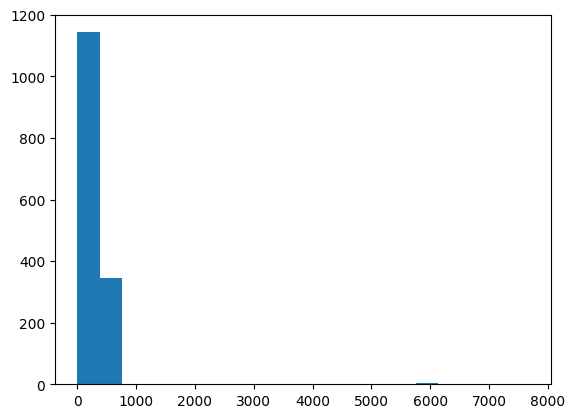

In [13]:
# histogram to see the distribution
plt.hist(x=df['unit_price'],bins=20)
plt.show()

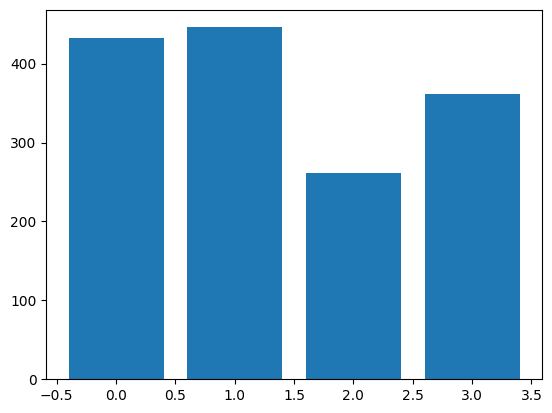

In [14]:
# bar chart
plt.bar(x=df['product_category'].value_counts().index,height=df['product_category'].value_counts().values)
plt.show()

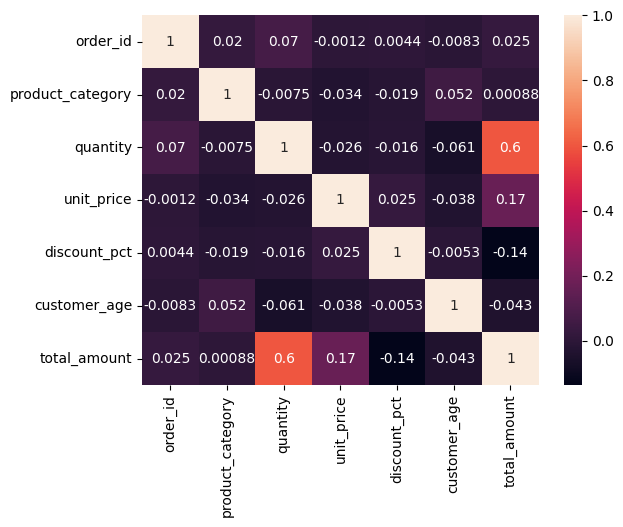

In [15]:
# correlation heatmap
sns.heatmap(df.corr(),annot=True)
plt.show()

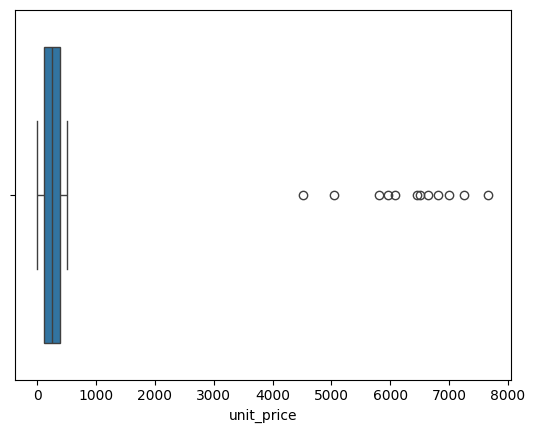

In [16]:
# boxplot to spot outliers in unit_price
sns.boxplot(x=df['unit_price'])
plt.show()

In [17]:
# identify outliers using the IQR method
Q1 = df['unit_price'].quantile(0.25)
Q3 = df['unit_price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['unit_price'] < lower_bound) | (df['unit_price'] > upper_bound)]
outliers

,order_id,product_category,quantity,unit_price,discount_pct,customer_age,total_amount
63,64,0,2,7664.75,27.2,32.0,659.92
102,103,1,3,5804.79,29.5,40.0,366.40
185,186,0,3,6635.93,25.4,25.0,265.56
457,458,1,5,6510.71,13.1,55.0,1298.16
614,615,3,3,6818.04,14.0,31.0,415.90
781,782,2,3,5952.92,28.7,43.0,557.23
783,784,2,6,4509.44,19.3,25.0,1520.39
1056,1057,0,7,7252.06,21.9,43.0,102.12
1087,1088,2,8,5049.52,1.4,34.0,3512.61
1204,1205,1,6,6085.66,19.6,48.0,546.80


In [18]:
# remove the outliers
df = df[(df['unit_price'] >= lower_bound) & (df['unit_price'] <= upper_bound)]
df.shape

(1488, 7)